In [ ]:
using Pkg
pkg_folder = "../"
Pkg.activate(pkg_folder)
using BenchmarkTools
import Markdown; Base.showable(::MIME"text/markdown", ::Markdown.MD) = false # to make sth like """?replace"""  works for vscode backend, remember to choose Jupyter kernel
include(pkg_folder*"src/initialize.jl")
Threads.nthreads() #

  Activating project at `~/Realizibility_index/bnc_julia`


24

## Test if all the vertex can be successfully reached

In [11]:
model = Bnc(L=L_generator(5,10,min_binder=2,max_binder=3))
idx_list = get_vertices(model,asymptotic=false, singular=false, return_idx=true)
is_success = Bool[]
for idx in  idx_list
    try get_vertex!(model,idx,full=true)
        push!(is_success,true)
    catch
        push!(is_success,false)
    end
end
sum(is_success) / length(is_success)

Start finding all vertices, it may takes a while.
Done, with 299 vertices found and 257 asymptotic vertices.
Start calculating nullity for each vertex, it may takes a while.
Done.
Start calculating verteices graph, It may takes a while.
Done.


1.0

## Seems drawing some plot to build some intuition about regimes 

In [108]:
L = [1 0 1 1
    0 1 1 1]
model = Bnc(L=L)

find_all_vertices!(model)

x_sample = randomize((4,100000))
vtx_asym_x = get_vertex_x(model, x_sample';asymtotic=true)
vtx_nonasym_x = get_vertex_x(model, x_sample';asymtotic=false)
vtx_asym_qK = [get_vertex_qK_slow(model, col ;asymtotic=true, q_calc_asym=false) for col in eachcol(x_sample)]
vtx_nonasym_qK = [get_vertex_qK_slow(model, col ;asymtotic=false, q_calc_asym=false) for col in eachcol(x_sample)]

# diff_idx = findall(vtx_asym .!= vtx_nonasym)
# idx_43 = findall(map(x->x==[4,3], vtx_nonasym))

logder_qK_x_ = [∂logqK_∂logx(model; x=x) for x in eachcol(x_sample)]
x = [mtx[1,3] for mtx in logder_qK_x_]
z = [mtx[2,3] for mtx in logder_qK_x_]
y = [mtx[2,4] for mtx in logder_qK_x_]


clr_asym_x = [model.vertices_idx[v] for v in vtx_asym_x]
clr_nonasym_x = [model.vertices_idx[v] for v in vtx_nonasym_x]
clr_asym_qK = [model.vertices_idx[v] for v in vtx_asym_qK]
clr_nonasym_qK = [model.vertices_idx[v] for v in vtx_nonasym_qK]

print("Done")

Done

In [ ]:
using GLMakie
fig = Figure(size = (2000, 2000))

(minval,maxval) = values(model.vertices_idx) |> x->(minimum(x),maximum(x))

ax = Axis3(fig[1,1],aspect = :equal,
    xlabel = "x",
    ylabel = "y",
    zlabel = "z", title = "asym_qK"
)
scatter!(ax, x, y, z, markersize=15, color = clr_asym_qK, colorrange = (minval,maxval),alpha=0.8)


ax2 = Axis3(fig[1,2],aspect = :equal,
    xlabel = "x",
    ylabel = "y",
    zlabel = "z", title = "nonsym_qK"
)
scatter!(ax2, x, y, z, markersize=15, color = clr_nonasym_qK, colorrange = (minval,maxval),alpha=0.8)


ax3 = Axis3(fig[2,1],aspect = :equal,
    xlabel = "x",
    ylabel = "y",
    zlabel = "z", title = "asym_x"
)
scatter!(ax3, x, y, z, markersize=15, color = clr_asym_x, colorrange =(minval,maxval),alpha=0.8)


ax4 = Axis3(fig[2,2],aspect = :equal,
    xlabel = "x",
    ylabel = "y",
    zlabel = "z", title = "nonasym_x"
)
scatter!(ax4, x, y, z, markersize=15, color = clr_nonasym_x, colorrange = (minval,maxval),alpha=0.8)

Colorbar(fig[:, 3], limits = crange, label = "Vertex Index", colormap = cgrad(cmap,maxval - minval+1,categorical=true))

# controls_master = cameracontrols(ax.scene)
# controls2 = cameracontrols(ax2.scene)
# controls3 = cameracontrols(ax3.scene)
# controls4 = cameracontrols(ax4.scene)

# # Link the properties of the other controls to the master controls
# on(controls_master.eyeposition) do val; controls2.eyeposition[] = val; controls3.eyeposition[] = val; controls4.eyeposition[] = val; end
# on(controls_master.lookat) do val; controls2.lookat[] = val; controls3.lookat[] = val; controls4.lookat[] = val; end
# on(controls_master.upvector) do val; controls2.upvector[] = val; controls3.upvector[] = val; controls4.upvector[] = val; end


# Display the plot
display(fig)

GLMakie.Screen(...)

In [95]:
v_dif = vector_difference(clr_nonasym_x, clr_nonasym_qK)

21-element Vector{Pair{Tuple{Int64, Int64}, Int64}}:
 (5, 7) => 145276
 (8, 6) => 104223
 (8, 7) => 90607
 (8, 3) => 79332
 (5, 4) => 69436
 (1, 6) => 13630
 (4, 6) => 9745
 (5, 2) => 7686
 (2, 7) => 4255
 (2, 3) => 1794
 (1, 3) => 1540
 (1, 2) => 273
 (1, 4) => 212
 (7, 6) => 104
 (1, 7) => 45
 (3, 7) => 8
 (7, 3) => 5
 (3, 6) => 5
 (6, 4) => 4
 (7, 4) => 2
 (4, 7) => 1

## Early test of catalysis involving

In [2]:
    #case1-------------
# #binding
N = [1 1 -1]
x_sym = [:E, :S, :C]
q_sym = [:tE, :tS]
K_sym = [:K]

#Catalysis
S = Matrix([0 -1]')# R1: tP's degrdation caused by P
    # -1 0   # R2: tP's degradation Caused by P2 
    #  1 0]') # R3: tP's synthesis

# aT = [0 0 1] # P cause R1 
#     #   0 1 0 0 # P2 cause R2
#     #   0 0 0 1] # C cause R3
cat_x_idx = [3]

k = [0.1] #catalysis rate

model = Bnc(N=N,
    x_sym=x_sym, q_sym=q_sym, K_sym=K_sym,
    S=S, k=k, cat_x_idx=cat_x_idx)

catalysis coefficients is set to 1 for all catalysis species as aT is not provided.


Bnc([1 1 -1], [1 0 1; 0 1 1], 1, 3, 2, Num[E, S, C], Num[tE, tS], Num[K], CatalysisData([0; -1; 0;;], [0 0 1], [0.1], [3], 1, sparse([2], [1], [-1.0], 3, 1), sparse([1], [3], [1.0], 1, 3)), Vector{Int64}[], Matrix{Int64}(undef, 0, 0), Matrix{Int64}(undef, 0, 0), Dict{Vector{Int64}, Any}(), -1, [0.0, 0.0, 0.0], [0.3010299956639812, 0.3010299956639812, 0.0], true, Dict{Vector{Int64}, Int64}(), sparse([1, 3, 2, 3], [1, 1, 2, 2], [1.0, 1.0, 1.0, 1.0], 3, 2), sparse([1, 3, 2, 3, 1, 2, 3], [1, 1, 2, 2, 3, 3, 3], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0], 3, 3), SparseArrays.UMFPACK.UmfpackLU{Float64, Int64}(SparseArrays.UMFPACK.Symbolic{Float64, Int64}(Ptr{Nothing} @0x00000000189f7790), SparseArrays.UMFPACK.Numeric{Float64, Int64}(Ptr{Nothing} @0x0000000014f348c0), 3, 3, [0, 2, 4, 7], [0, 2, 1, 2, 0, 1, 2], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0], 0, SparseArrays.UMFPACK.UmfpackWS{Int64}([1812476199307, 1821066133926, 1872605741490], [9.867280430276e-312, 1.0228019712453e-311, 1.048265920977e-311]),

In [3]:
x_traj = x_traj_with_q_change(model, [1,10],[1,0.1]; K=[0.1],output_logspace=true)

([0.0, 0.029973886576517752, 0.06873730627627093, 0.10988519068832855, 0.1553214888127607, 0.20256856434640985, 0.2518084030700384, 0.302562254054387, 0.35597901916162855, 0.4193592357903773, 0.471283071425804, 0.5253922854118805, 0.580148644363612, 0.6373456810086011, 0.6971612661159939, 0.7606375201224116, 0.8284216587580286, 0.9014863215248288, 0.9808023359064889, 1.0], [-0.9162060039085121 0.9600558515089294 -0.05615015239958262; -0.85941507005764 0.8948092287541216 -0.06460584130351817; … ; -0.020936857263467824 -1.2063623362337703 -1.3272991934972376; -0.019170976049534598 -1.2455193394150892 -1.3646903154646233])

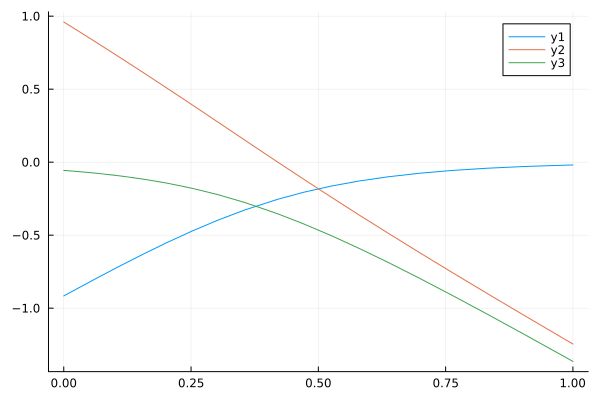

In [4]:
plot(x_traj)

In [ ]:
t = 0.0:0.1:400
sol = catalysis_logx(bnc_test,qK2x(bnc_test, [100,1000,1];output_logspace=true), (t[1], t[end]))

retcode: Success
Interpolation: 3rd order Hermite
t: 52-element Vector{Float64}:
   0.0
   0.08574408432686294
   0.7019095916859328
   4.362826346802653
  14.055617755791378
  25.685004906562888
  37.127819887486694
  48.517712357106
  58.778747855933204
  66.47632012583709
  72.22106417073695
  76.49258980972184
  79.6627002629106
   ⋮
 136.54837931632747
 143.89539989575738
 153.1017779345753
 163.72142759351405
 175.7509156481193
 189.94613233690004
 206.78729735400714
 227.3530436322011
 253.17781154466522
 287.13260251924066
 334.80538852764755
 400.0
u: 52-element Vector{Vector{Float64}}:
 [-2.1984582309131464, 6.802518059392708, 4.604059828479591]
 [-2.197507415188501, 6.801566186833489, 4.604058771645018]
 [-2.190648074353429, 6.794699191940921, 4.604051117587521]
 [-2.1488952772104875, 6.752898653565413, 4.604003376354954]
 [-2.0291278095704213, 6.63298262957718, 4.603854820006786]
 [-1.8635226295741287, 6.467140358884179, 4.603617729310077]
 [-1.6685388047778527, 6.271821988

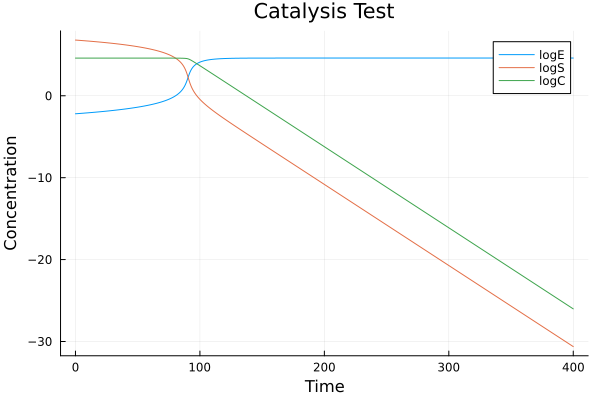

In [ ]:
logx = sol.(t)|> (x -> stack(x,dims=1))
x = exp.(logx)
logqK = eachrow(logx) .|> (x->x2qK(bnc_test,x,input_logspace=true, output_logspace=true)) |> (x -> stack(x,dims=1))  # convert sol to qK
qK = exp.(logqK) # convert logqK to qK
# # "log" .* string.([bnc_test.q_sym; bnc_test.K_sym]')
# # label=[bnc_test.q_sym; bnc_test.K_sym]'
# plot(t,logqK, xlabel="Time", ylabel="Concentration", title="Catalysis Test",label="log" .* string.([bnc_test.q_sym; bnc_test.K_sym]'), legend=:topright)
plot(t,logx, xlabel="Time", ylabel="Concentration", title="Catalysis Test",label="log" .* string.([bnc_test.x_sym;]'), legend=:topright)

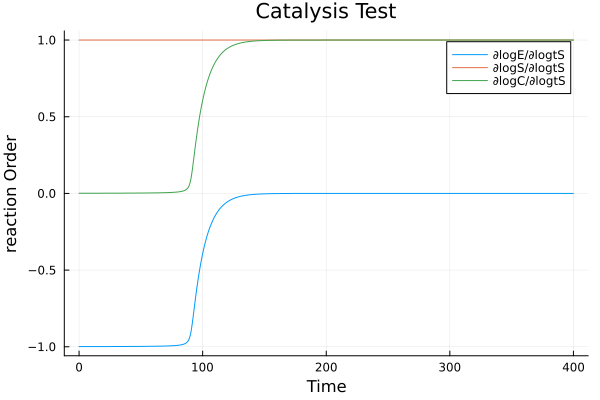

In [ ]:
logtS = logx[:,2]
δlogx = logx[2:end,:] .- logx[1:end-1,:]
δlogtS = logtS[2:end] .- logtS[1:end-1]

∂logx_∂logtS = δlogx ./ δlogtS
t2 = t[2:end] .- (t[2]-t[1])/2 # shift time to the middle of the interval

label = "∂log" .* string.(bnc_test.x_sym) .* "/∂logtS"
plot(t2, ∂logx_∂logtS, xlabel="Time", ylabel="reaction Order", title="Catalysis Test", label=hcat(label...), legend=:topright)

In [ ]:
find_valid_regime(bnc_test)

4-element Vector{Vector{Int64}}:
 [1, 2]
 [1, 3]
 [3, 2]
 [3, 3]

In [ ]:
valid_regime = []
logder_x_ts_regime = []
for regime in find_valid_regime(bnc_test)
    M,singularity =  ∂logx_∂logqK_regime(bnc_test,regime=regime)
    if singularity == 0
        logder_x_ts = M[:,2]
        push!(logder_x_ts_regime, logder_x_ts)
        push!(valid_regime, regime)
    end
end

In [ ]:
    #case1-------------
# #binding
N = [1 0 -1 0
    0 1 1 -1]
# L = [
# 	1 0 1
# 	0 1 1
# 	]
x_sym = [:P, :P2, :DNA, :C]
q_sym = [:tP, :tD]
K_sym = [:K1, :K2]

#Catalysis
S = Matrix([-1 0  # R1: tP's degrdation caused by P
    -1 0   # R2: tP's degradation Caused by P2 
     1 0]') # R3: tP's synthesis

aT = [1 0 0 0 # P cause R1 
      0 1 0 0 # P2 cause R2
      0 0 0 1] # C cause R3

k = [0.1, 0.1, 1 ] #catalysis rate

bnc_test = Bnc(N=N,
    # L=L,
    x_sym=x_sym, q_sym=q_sym, K_sym=K_sym,
    S=S, aT=aT, k=k)

sol = catalysis_logx(bnc_test,ones(bnc_test.n), (0.0, 10.0))

retcode: Success
Interpolation: 3rd order Hermite
t: 12-element Vector{Float64}:
  0.0
  0.04949422525756363
  0.31468966589877334
  1.034240721579605
  1.9278840093736045
  2.928834962987815
  4.218039231063516
  5.4090162126185595
  6.767159022844265
  8.198028486211149
  9.741445643062843
 10.0
u: 12-element Vector{Vector{Float64}}:
 [1.0, 1.0, 1.0, 1.0]
 [1.0056558545607892, 0.9943281511790766, 1.0113117091215786, 1.005639860300655]
 [1.035926813561559, 0.9634279572576009, 1.0718536271231183, 1.035281584380719]
 [1.1174353673670594, 0.875684891290688, 1.2348707347341192, 1.1105556260248073]
 [1.2162114499856225, 0.7605947259026697, 1.4324228999712458, 1.1930176258739156]
 [1.3217893320921603, 0.6273060806110993, 1.6435786641843213, 1.2708847447954206]
 [1.447577029463345, 0.4554361106689698, 1.8951540589266906, 1.3505901695956604]
 [1.5525082517610878, 0.30204581732669616, 2.1050165035221764, 1.4070623208488726]
 [1.6591633877717538, 0.13770874082025522, 2.3183267755435084, 1.45603

### 2. Test of Catalysis Involving, Repressilator

In [ ]:
x_sym = [:P1, :D1, :P2, :D2, :P3, :D3, :C1, :C2, :C3]

N = [1 1 0 0 0 0 -1 0 0 
     0 0 1 1 0 0 0 -1 0
     0 0 0 0 1 1 0 0 -1
    ]

q_sym = [:tP1, :tD1, :tP2, :tD2, :tP3, :tD3]

S = Matrix([-1 0 0 0 0 0  
             0 0 -1 0 0 0
             0 0 0 0 -1 0
             -1 0 0 0 0 0  
             0 0 -1 0 0 0
             0 0 0 0 -1 0
             1 0 0 0 0 0 
             0 0 1 0 0 0  
             0 0 0 0 1 0 ]')  

K_sym = [:K1, :K2, :K3]

#Catalysis
            # :tP1, :tP2, :tP3, :tD1, :tD2, :tD3


aT = [  1 0 0 0 0 0 0 0 0 
        0 0 1 0 0 0 0 0 0 
        0 0 0 0 1 0 0 0 0
        0 0 0 0 0 0 1 0 0 
        0 0 0 0 0 0 0 1 0 
        0 0 0 0 0 0 0 0 1
 
        0 0 0 0 0 1 0 0 0 
        0 1 0 0 0 0 0 0 0 
        0 0 0 1 0 0 0 0 0]

degrate = 0.02
birthrate = 1.0
k = [repeat([degrate],6); repeat([birthrate],3) ] #catalysis rate

bnc_test = Bnc(N=N,
    # L=L,
    x_sym=x_sym, q_sym=q_sym, K_sym=K_sym,
    S=S, aT=aT, k=k)

Bnc([1 1 … 0 0; 0 0 … -1 0; 0 0 … 0 -1], [1 0 … 0 0; 0 1 … 0 0; … ; 0 0 … 0 1; 0 0 … 0 1], 3, 9, 6, Num[P1, D1, P2, D2, P3, D3, C1, C2, C3], Num[tP1, tD1, tP2, tD2, tP3, tD3], Num[K1, K2, K3], -1, [-1 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0], [1 0 … 0 0; 0 0 … 0 0; … ; 0 1 … 0 0; 0 0 … 0 0], [0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 1.0, 1.0, 1.0], 9, [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.6931471805599453, 0.6931471805599453, 0.6931471805599453, 0.6931471805599453, 0.6931471805599453, 0.6931471805599453, 0.0, 0.0, 0.0], true, sparse([1, 7, 2, 7, 3, 8, 4, 8, 5, 9, 6, 9], [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 9, 6), sparse([1, 7, 2, 7, 3, 8, 4, 8, 5, 9  …  9, 1, 2, 7, 3, 4, 8, 5, 6, 9], [1, 1, 2, 2, 3, 3, 4, 4, 5, 5  …  6, 7, 7, 7, 8, 8, 8, 9, 9, 9], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, -1.0, 1.0, 1.0, -1.0, 1.0, 1.0, -1.0], 9, 9), SparseArrays.UMFPACK.UmfpackLU{Float64, Int64}(Spars

In [ ]:
reduce(hcat, @."log" * string(bnc_test.x_sym))


1×9 Matrix{String}:
 "logP1"  "logD1"  "logP2"  "logD2"  …  "logD3"  "logC1"  "logC2"  "logC3"

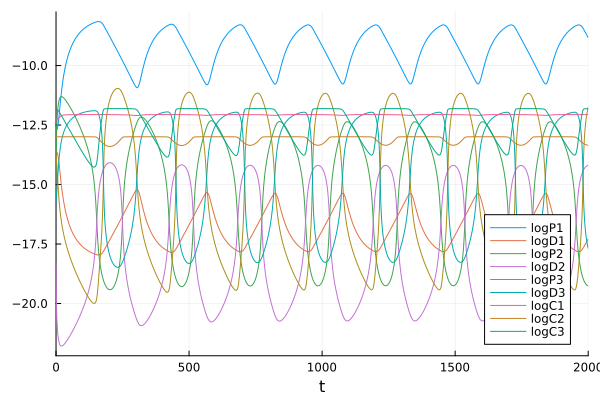

In [ ]:
t = 0.0:0.1:2000
tP = randomize(3,-7,-5)
tD = randomize(3,-6,-5)
K = randomize(3,-9,-5)
degrate = 0.02
birthrate = 1
bnc_test.k = [repeat([degrate],6); repeat([birthrate],3) ]
sol = catalysis_logx(bnc_test,qK2x(bnc_test, [reduce(hcat,hcat.(tP,tD))[:]; K];output_logspace=true), (t[1], t[end]))
plot(sol,label= reduce(hcat, @."log" * string(bnc_test.x_sym)))

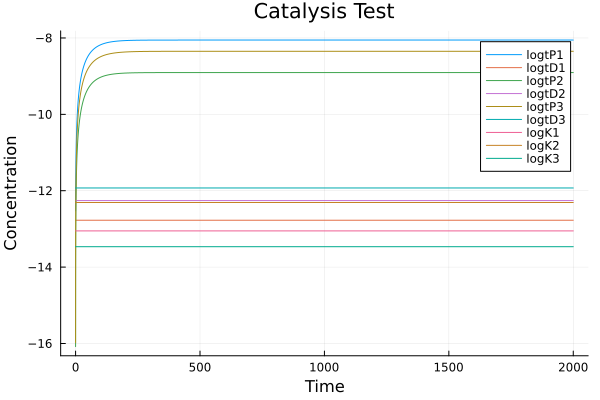

In [ ]:
logx = sol.(t)|> (x -> stack(x,dims=1))
x = exp.(logx)
logqK = eachrow(logx) .|> (x->x2qK(bnc_test,x,input_logspace=true, output_logspace=true)) |> (x -> stack(x,dims=1))  # convert sol to qK
qK = exp.(logqK) # convert logqK to qK
# # "log" .* string.([bnc_test.q_sym; bnc_test.K_sym]')
# # label=[bnc_test.q_sym; bnc_test.K_sym]'
plot(t,logqK, xlabel="Time", ylabel="Concentration", title="Catalysis Test",label="log" .* string.([bnc_test.q_sym; bnc_test.K_sym]'), legend=:topright)
# plot(t,logx, xlabel="Time", ylabel="Concentration", title="Catalysis Test",label="log" .* string.([bnc_test.x_sym;]'), legend=:topright)

## Try drawing reaction Order Polehedra

In [ ]:

# Pr  SB NB CS CN
N2 = [1 1 0 -1 0 0
    2 1 1 0 -1 0
    1 0 1 0 0 -1]

bnc_test2 = bnc(N=N2)

logx_traj_with_logqK_change(bnc_test2, [], []; input_logspace=false, output_logspace=false)


#case3---------
# @btime let
N3 = N_generator(95, 100; min_binder=2, max_binder=5)
bnc_test3 = bnc(N=N3)

#find ss point
qK = vcat(randomize(bnc_test3.d, -6, 6), randomize(bnc_test3.r, -3, 3))
@btime qK2x(bnc_test3, qK)

qK_end = vcat(randomize(bnc_test3.d, -6, 6), randomize(bnc_test3.r, -3, 0))

@btime let
    bnc_test3 = bnc(N=N3)
    qK2x(bnc_test3, qK)
end
#3.862 3.863
#3.915

relerror = qK2x(bnc_test3, qK; output_logspace=true) |> (x -> x2qK(bnc_test3, x, input_logspace=true)) |> (x -> x ./ qK .- 1)
hist(relerror * 100, bins=100)
# original 1.411s; 14713 allocations; 

@btime sol = logx_traj_with_logqK_change(bnc_test3, log.(qK), log.(qK_end); reltol=1e-8, abstol=1e-9) #bdf solver
plot(sol)
# end

#case4---------

N4 = [0 -1 -1 1 0
    -1 0 0 -1 1]
bnc4 = bnc(N=N4)

x = randomize(bnc4.n * 100000, -6, 6; log_space=true) |> (x -> reshape(x, bnc4.n, 100000))
function rop_C(x)
    ∂logx_∂logqK(bnc4; x=x)[5, 1:3]
end
points = [rop_C(x[:, i]) for i in 1:size(x, 2)] |> (x -> reduce(hcat, x))
# plot the points
fig = Figure(size=(1920, 1080))
ax = Axis3(fig[1, 1],
    title="3D Scatter Plot of Reaction Order Points",
    xlabel="∂logCGRS/∂logtG",
    ylabel="∂logCGRS/∂logtR",
    zlabel="∂logCGRS/∂logtS",
    aspect=:data,
)
GLMakie.scatter!(ax,
    points[1, :], points[2, :], points[3, :];
    color=(:cyan, 0.5), markersize=6)


# case 5----------
N5 = [1 1 0 -1 0 0
    1 0 1 0 -1 0
    # 0 1 0 0 1 -1
    0 0 1 1 0 -1]
bnc5 = bnc(N=N5)


#fucntion test ------------
# qK2x_test(bnc_test,randomize(3,-6,6)) |> (x -> plot!(x, idxs=(1,2,3),legend = false))
model = bnc_test
test_x = [1.e-6, 2e3, 3e-2]
for i in 1:10000
    test_x = x2qK(model, test_x)
    test_x = qK2x(model, test_x)
end

# S_tot_grow
sol = logx_traj_with_logqK_change(bnc_test, [2, -10, 1.0e-9], [2, 10, 1.0e-9], reltol=1e-8, abstol=1e-9)
plot(sol)

logx0 = qK2x(bnc_test, [1.0e1, 1.0e2, 1.0e-1]; output_logspace=true)
time_curve_logx(bnc_test, logx0, (0.0, 150.); reltol=1e-8, abstol=1e-9) |> plot

LoadError: UndefVarError: `bnc` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Trying using the DAE method to solve homotopy odes

In [2]:
import Sundials

In [24]:
function _logx_traj_with_logqK_change_test(Bnc::Bnc,
    startlogqK::Union{Vector{<:Real},Nothing},
    endlogqK::Vector{<:Real};
    startlogx::Union{Vector{<:Real},Nothing}=nothing,
    reltol=1e-8,
    abstol=1e-9,
    kwargs... 
)::DAESolution
    n = Bnc.n
    d = Bnc.d
    u0 = isnothing(startlogx) ? qK2x(Bnc, startlogqK; input_logspace=true, output_logspace=true) : startlogx
    #Homotopy path in log-space( a straight line)
    ΔlogqK = Float64.(endlogqK - startlogqK)
    # Create thread-local copies of all mutable data structures
    logqK = Vector{Float64}(undef, n)

    L = Bnc.L
    N = Bnc.N

    ln10 = log(10.0)
    # A(u,t) = [ diag(1/q(t)) * L * diag(x(u)) ; N ]
    A(u, t) = begin
        logqK .= t .* ΔlogqK .+ startlogqK
        q = exp10.(logqK[1:d])
        x = exp10.(u)
        [diagm(1.0 ./ q) * L * diagm(x);
         N]
    end

    # Residual: F(du,u,t) = A(u,t)*du - ΔlogqK = 0
    function f(resid, du, u, p, t)
        resid .= A(u, t) * du .- ΔlogqK
        return nothing
    end
    # J = ∂F/∂u + γ ∂F/∂du
    function jac(J, du, u, p, gamma, t)
        logqK .= t .* ΔlogqK .+ startlogqK
        q = exp10.(logqK[1:d])
        x = exp10.(u)
        A_top = Diagonal(1.0 ./ q) * L * Diagonal(x)                 # ∂F/∂du top-block
        dA_du_top = Diagonal(1.0 ./ q) * L * Diagonal(x .* (ln10 .* du))  # ∂F/∂u top-block
        # Stack top and bottom blocks
        J .= [dA_du_top + gamma .* A_top; gamma .* N]
        return nothing
    end

    func = DAEFunction(f; jac=jac, jac_prototype = sparse([L; N]))

    tspan = (0.0, 1.0)

    # Consistent du0 at t = 0
    A0 = A(u0, 0.0)
    du0 = A0 \ ΔlogqK  # least-squares if A0 is rectangular

    prob = DAEProblem(func, du0, u0, tspan, nothing)
    sol = solve(prob, Sundials.IDA(linear_solver=:KLU); reltol=reltol, abstol=abstol, kwargs...)
    return sol
end

_logx_traj_with_logqK_change_test (generic function with 1 method)

In [84]:
_logx_traj_with_logqK_change_test3(model, randomize(model.n), randomize(model.n); reltol=1e-8, abstol=1e-9)

LoadError: Must supply differential_vars argument to DAEProblem constructor to use IDA initial value solver.

In [47]:
@btime _logx_traj_with_logqK_change(model, randomize(model.n), randomize(model.n); reltol=1e-8, abstol=1e-9)

  12.211 ms (51484 allocations: 42.74 MiB)


retcode: Success
Interpolation: 3rd order Hermite
t: 33-element Vector{Float64}:
 0.0
 0.028560029461094524
 0.045365709345039536
 0.06717318864515898
 0.08703927972536099
 0.1100915046842468
 0.13618626139385617
 0.15920808202616732
 0.18463719078243593
 0.2105681276681026
 0.2387096096576652
 0.2688905355535924
 0.30159543339217254
 ⋮
 0.6111371196135349
 0.6484808162829946
 0.6902996686000844
 0.7344137306321877
 0.778119468150657
 0.8193322030693756
 0.8563862488917708
 0.8898858427720322
 0.9233978522383195
 0.9559505839284378
 0.986550080846883
 1.0
u: 33-element Vector{Vector{Float64}}:
 [-5.306302928333904, -16.225701776115717, 4.532034675320007, -2.3768413889278617, -5.2381786511717, 2.598725643508523, -2.2529676812670276, -10.27190809679221, 1.5557592301090382, -5.901053766766936  …  -1.4651641599793201, -13.212794326622987, -15.13428970354176, -5.023509456397964, -24.4154099412894, -27.18840671217634, -13.216193427751561, -5.624532956021376, -8.23488587240859, -10.5250504127

In [67]:
function _logx_traj_with_logqK_change_test3(Bnc::Bnc,
    startlogqK::Vector{<:Real},
    endlogqK::Vector{<:Real};
    startlogx::Union{Vector{<:Real},Nothing}=nothing,
    reltol=1e-8,
    abstol=1e-9,
    kwargs...
)::DAESolution

    n = Bnc.n
    d = Bnc.d
    r = Bnc.r
    @assert length(startlogqK) == d + r "startlogqK length must be d+r"
    @assert length(endlogqK)   == d + r "endlogqK length must be d+r"

    u0 = isnothing(startlogx) ? qK2x(Bnc, startlogqK; input_logspace=true, output_logspace=true) : startlogx
    @assert length(u0) == n

    ΔlogqK = Float64.(endlogqK .- startlogqK)
    logqK = similar(ΔlogqK)  # length d+r

    L = Bnc.L
    N = Bnc.N
    ln10 = log(10.0)

    # -------- 构造 Float64 型稀疏 Jacobian 原型（结构 = [L;N]）--------
    base = [L; N]                       # (d+r) × n
    base_sp_int = sparse(base)          # 先拿结构
    Jcolptr = copy(base_sp_int.colptr)
    Jrowval = copy(base_sp_int.rowval)
    Jnzval  = zeros(Float64, length(base_sp_int.nzval))
    jac_prototype = SparseMatrixCSC{Float64,Int}(size(base_sp_int,1), size(base_sp_int,2),
                                                 Jcolptr, Jrowval, Jnzval)

    # 预分离上/下块判断
    cutoff_row = d

    # Residual: F(du,u,t) = A(u,t)*du - ΔlogqK
    # A 上块 (d×n): (1/q_i) * L_ij * x_j
    # A 下块 (r×n): N_kj
    function f(resid, du, u, p, t)
        @inbounds begin
            @. logqK = t * ΔlogqK + startlogqK
            q = exp10.(view(logqK, 1:d))
            x = exp10.(u)

            # 计算 A*du （只用结构 [L;N]）
            # resid 长度应为 d+r；如果 n ≠ d+r 这里数学不一致，会报错
            @assert length(resid) == d + r "Residual dimension mismatch (model not square)."

            # 上块
            idx = 1
            for col in 1:n
                col_start = Jcolptr[col]
                col_end   = Jcolptr[col+1]-1
                for ptr in col_start:col_end
                    row = Jrowval[ptr]
                    if row <= cutoff_row
                        # row in 1:d  -> L[row,col] 只在结构中出现（非零）
                        # A_rowcol = (1/q_row) * L[row,col] * x[col]
                        # 存临时：我们直接累乘 du[col]
                        # 找到原 L 值（需要数组 L）：
                        # L[row,col] 已知，因为结构来自 L;N，非零即 L[row,col]
                        # 但仍要安全：取 L[row,col]
                        # 先累加 resid[row]
                        resid[row] += (L[row,col] / q[row]) * x[col] * du[col]
                    else
                        # 下块 row = d + k
                        k = row - cutoff_row
                        resid[row] += N[k,col] * du[col]
                    end
                end
            end

            # 减去 ΔlogqK
            @. resid = resid - ΔlogqK
        end
        return nothing
    end

    # jac: J = ∂F/∂u + γ ∂F/∂du
    # 对上块： F_i = Σ_j (1/q_i)L_ij x_j du_j   − ΔlogqK_i
    # ∂F_i/∂du_j = (1/q_i)L_ij x_j
    # ∂F_i/∂u_j  = (1/q_i)L_ij (∂/∂u_j)(x_j) du_j = (1/q_i)L_ij x_j ln(10) du_j
    # => top J_ij = (1/q_i)L_ij x_j ( ln10*du_j + γ )
    # 下块：F_{d+k} = Σ_j N_kj du_j - ΔlogqK_{d+k}
    # => ∂F/∂du_j = N_kj ; ∂F/∂u_j = 0
    # => bottom J_{d+k,j} = γ * N_kj
    function jac(J, du, u, p, gamma, t)
        @inbounds begin
            @. logqK = t * ΔlogqK + startlogqK
            q = exp10.(view(logqK,1:d))
            x = exp10.(u)

            nzval = J.nzval
            rowval = J.rowval
            colptr = J.colptr

            for col in 1:n
                fac_du = ln10 * du[col] + gamma  # 只用于上块
                col_start = colptr[col]
                col_end   = colptr[col+1]-1
                for ptr in col_start:col_end
                    row = rowval[ptr]
                    if row <= cutoff_row
                        # 上块
                        valL = L[row,col]
                        nzval[ptr] = (valL / q[row]) * x[col] * fac_du
                    else
                        # 下块
                        k = row - cutoff_row
                        nzval[ptr] = gamma * N[k,col]
                    end
                end
            end
        end
        return nothing
    end

    func = DAEFunction(f; jac=jac, jac_prototype=jac_prototype)

    tspan = (0.0, 1.0)

    # 生成一致初值 du0：解 A(u0,0)*du0 = ΔlogqK
    # A(u0,0) 用同样公式（只算一次）
    A_mul_du!(y, du, u) = begin
        fill!(y, 0.0)
        @inbounds begin
            q0 = exp10.(view(startlogqK,1:d))
            x0 = exp10.(u)
            # 上块
            for col in 1:n
                for ptr in Jcolptr[col]:(Jcolptr[col+1]-1)
                    row = Jrowval[ptr]
                    if row <= d
                        y[row] += (L[row,col] / q0[row]) * x0[col] * du[col]
                    else
                        k = row - d
                        y[row] += N[k,col] * du[col]
                    end
                end
            end
        end
        y
    end

    # 求 least-squares：使用迭代 (简单正常方程)；也可调用 \ 构造显式稠密 A (小规模可接受)
    A_dense = Array{Float64}(base)                  # (d+r)×n
    q0 = exp10.(view(startlogqK,1:d))
    x0 = exp10.(u0)
    # 构造 A0 数值
    for col in 1:n, row in 1:d
        A_dense[row,col] = (L[row,col] / q0[row]) * x0[col]
    end
    for col in 1:n, k in 1:r
        A_dense[d+k, col] = N[k,col]
    end
    du0 = A_dense \ ΔlogqK                # 最小二乘

    prob = DAEProblem(func, du0, u0, tspan, nothing)
    sol = solve(prob, Sundials.IDA(linear_solver=:KLU); reltol=reltol, abstol=abstol, kwargs...)
    return sol
end

_logx_traj_with_logqK_change_test3 (generic function with 1 method)

In [30]:
f1(x,y,g=1) = (1 - (minimum([x+y,g]))/(g))
f(x,y,K1=0.0001,K2=0.0001) = 1/(1+x/K1+y/K2)

f (generic function with 3 methods)

In [31]:
xs = LinRange(-6, 6, 100)
ys = LinRange(-6, 6, 100)
zs = [f1(x,y) for x in exp10.(xs), y in exp10.(ys)]
fig = Figure()
ax = Axis3(fig[1, 1], xlabel="x", ylabel="y", zlabel="f(x,y)", title="3D Surface Plot of f(x,y)")
surface!(ax, xs, ys, zs, colormap = :viridis)
display(fig)

GLMakie.Screen(...)

## While buggy, but might be fast regime find functions

In [13]:

function _vtxs_nonasym2(L, ::Val{T} ;eps=1e-9) where T
    d, n = size(L)
    # Nonzero indices of each row
    J = [findall(!iszero, row) for row in eachrow(L)]
    
    order = sortperm(J, by=length, rev=true)
    inv_order = invperm(order)
    J_ord = J[order]

    # Precompute VertexEdge weights: Dict[u => edges] for each row
    row_edges = map(1:d) do i
        Ji = J[i]
        logL = log.(L[i, Ji])  # compute once per row
        Dict(Ji[k] => [(Ji[m], -((logL[m] - logL[k]) + eps)) for m in eachindex(Ji) if m != k]
             for k in eachindex(Ji))
    end

    # adjacency list of weighted directed edges
    adj = [Vector{Tuple{T,Float64}}() for _ in 1:n]
    results = Vector{Vector{T}}()

    # -------- SPFA workspace (reused) ----------
    dist_local = fill(Inf, n)
    inq = falses(n)
    cnt = zeros(T, n)
    q = Vector{T}(undef, n)
    touched = Vector{Int}()   # nodes we need to reset
    # -------------------------------------------

    function has_neg_cycle(seeds)
        # reset only touched nodes after run
        empty!(touched)
        # init seeds
        q_in = 0
        q_out = 1
        @inbounds for u in seeds
            if dist_local[u] == Inf
                push!(touched, u)
            end
            dist_local[u] = 0.0
            inq[u] = true
            q_in += 1
            q[q_in] = u
        end

        # main loop
        while q_out <= q_in
            @inbounds u = q[q_out]; q_out += 1
            inq[u] = false
            du = dist_local[u]
            @inbounds for (v, w) in adj[u]
                nd = du + w
                if nd + 1e-15 < dist_local[v]
                    if dist_local[v] == Inf
                        push!(touched, v)
                    end
                    dist_local[v] = nd
                    if !inq[v]
                        q_in += 1
                        q[q_in] = v
                        inq[v] = true
                        cnt[v] += 1
                        if cnt[v] > n
                            # reset before exit
                            @inbounds for t in touched
                                dist_local[t] = Inf
                                inq[t] = false
                                cnt[t] = 0
                            end
                            return true
                        end
                    end
                end
            end
        end

        # reset workspace
        @inbounds for t in touched
            dist_local[t] = Inf
            inq[t] = false
            cnt[t] = 0
        end
        return false
    end

    function dfs(r, chosen)
        if r > d
            push!(results, chosen[inv_order])
            return
        end
        row = order[r]
        for u in J_ord[r]
            oldlen = length(adj[u])
            @inbounds append!(adj[u], row_edges[row][u])
            if !has_neg_cycle(J_ord[r])
                push!(chosen, u)
                dfs(r+1, chosen)
                pop!(chosen)
            end
            resize!(adj[u], oldlen)  # rollback edges
        end
    end

    dfs(1, Int[])
    return results
end

function _vtxs_asym2(L, ::Val{T}) where T
    d, n = size(L)
    J = [findall(x -> x != 0, row) for row in eachrow(L)]
    order = sortperm(J, by = length, rev=true)
    inv_order = invperm(order)
    J_ord = J[order]

    graph = [T[] for _ in 1:n]
    results = Vector{Vector{T}}()

    # preallocated DFS stack and visited stamps
    stack = Vector{T}(undef, n)
    visited_stamp = zeros(Int, n)
    stamp_ref = Ref(0)

    # fast DFS from src, marking visited via stamps
    @inline function dfs_mark!(src)::Int
        stamp_ref[] += 1
        curstamp = stamp_ref[]
        top = 1
        stack[1] = src
        visited_stamp[src] = curstamp
        @inbounds while top > 0
            u = stack[top]; top -= 1
            for w in graph[u]
                if visited_stamp[w] != curstamp
                    visited_stamp[w] = curstamp
                    top += 1
                    stack[top] = w
                end
            end
        end
        return curstamp
    end

    function dfs(r,chosen)
        if r > d
            push!(results, chosen[inv_order])
            return
        end

        row_choices = J_ord[r]
        @inbounds for v in row_choices
            # single DFS from v, then test all k in this row
            curstamp = dfs_mark!(v)
            bad = false
            @inbounds for k in row_choices
                k == v && continue
                if visited_stamp[k] == curstamp
                    bad = true
                    break
                end
            end
            bad && continue

            # add edges k -> v for k != v
            @inbounds for k in row_choices
                k == v && continue
                push!(graph[k], v)
            end

            push!(chosen, v)
            dfs(r + 1,chosen)
            pop!(chosen)

            # remove added edges (LIFO)
            @inbounds for k in reverse(row_choices)
                k == v && continue
                pop!(graph[k])
            end
        end
    end
    dfs(1,T[])
    return results
end

_vtxs_asym2 (generic function with 1 method)

In [ ]:
#--------------Core computation functions-------------------------
function _vtxs_nonasym3(L, ::Val{T} ;eps=1e-9) where T
    d, n = size(L)

    # 非零列索引
    J = [findall(!iszero, row) for row in eachrow(L)]
    order = sortperm(J, by=length, rev=true)
    inv_order = invperm(order)
    J_ord = J[order]

    # 预计算每行的加权边，避免重复 log
    row_edges = map(1:d) do i
        Ji = J[i]
        logL = log.(L[i, Ji])
        # u -> [(v, weight)...]，权重按 -((logL[v]-logL[u]) + eps)
        Dict(Ji[k] => [(Ji[m], -((logL[m] - logL[k]) + eps)) for m in eachindex(Ji) if m != k]
            for k in eachindex(Ji))
    end

    # 全局增量图（带权有向边）
    adj = [Vector{Tuple{T,Float64}}() for _ in 1:n]
    results = Vector{Vector{T}}()

    # --------- 零分配 SPFA 工作区（复用） ----------
    dist = fill(Inf, n)
    inq = falses(n)
    cnt = zeros(T, n)
    q = Vector{T}(undef, n)   # 环形队列缓冲
    touched = Vector{Int}()   # 记录本轮触达的节点，便于局部重置
    # ------------------------------------------------

    function has_neg_cycle(seeds)::Bool
        empty!(touched)
        # 初始化队列
        q_in = 0
        q_out = 1
        @inbounds for u in seeds
            if dist[u] == Inf
                push!(touched, u)
            end
            dist[u] = 0.0
            inq[u] = true
            q_in += 1
            q[q_in] = u
        end

        while q_out <= q_in
            @inbounds u = q[q_out]; q_out += 1
            inq[u] = false
            du = dist[u]
            @inbounds for (v, w) in adj[u]
                nd = du + w
                if nd + 1e-15 < dist[v]
                    if dist[v] == Inf
                        push!(touched, v)
                    end
                    dist[v] = nd
                    if !inq[v]
                        q_in += 1
                        q[q_in] = v
                        inq[v] = true
                        cnt[v] += 1
                        if cnt[v] > n
                            # 局部重置后返回
                            @inbounds for t in touched
                                dist[t] = Inf
                                inq[t] = false
                                cnt[t] = 0
                            end
                            return true
                        end
                    end
                end
            end
        end

        # 局部重置
        @inbounds for t in touched
            dist[t] = Inf
            inq[t] = false
            cnt[t] = 0
        end
        return false
    end

    function dfs(r, chosen::Vector{T})
        if r > d
            push!(results, chosen[inv_order])
            return
        end
        row = order[r]
        row_choices = J_ord[r]
        @inbounds for u in row_choices
            oldlen = length(adj[u])
            append!(adj[u], row_edges[row][u])
            if !has_neg_cycle(row_choices)
                push!(chosen, u)
                dfs(r + 1, chosen)
                pop!(chosen)
            end
            resize!(adj[u], oldlen) # 回滚增量边
        end
    end

    dfs(1, T[])
    return results
end

function _vtxs_asym3(L, ::Val{T}) where T
    d, n = size(L)
    J = [findall(!iszero, row) for row in eachrow(L)]
    order = sortperm(J, by = length, rev=true)
    inv_order = invperm(order)
    J_ord = J[order]

    # 增量 DAG
    graph = [T[] for _ in 1:n]
    results = Vector{Vector{T}}()

    # 预分配栈与访问戳
    stack = Vector{T}(undef, n)
    visited_stamp = zeros(Int, n)
    stamp_ref = Ref(0)

    # 从 src 单次 DFS 标记可达集合（访问戳避免清空）
    @inline function dfs_mark!(src)::Int
        stamp_ref[] += 1
        curstamp = stamp_ref[]
        top = 1
        stack[1] = src
        visited_stamp[src] = curstamp
        @inbounds while top > 0
            u = stack[top]; top -= 1
            for w in graph[u]
                if visited_stamp[w] != curstamp
                    visited_stamp[w] = curstamp
                    top += 1
                    stack[top] = w
                end
            end
        end
        return curstamp
    end

    function dfs(r, chosen::Vector{T})
        if r > d
            push!(results, chosen[inv_order])
            return
        end

        row_choices = J_ord[r]
        @inbounds for v in row_choices
            # 若行内存在 k 使 v→…→k（v 可达 k），则加边 k→v 将成环，剪枝
            curstamp = dfs_mark!(v)
            bad = false
            @inbounds for k in row_choices
                k == v && continue
                if visited_stamp[k] == curstamp
                    bad = true
                    break
                end
            end
            bad && continue

            # 安全：添加 k→v（k≠v），回溯时 LIFO 弹出
            @inbounds for k in row_choices
                k == v && continue
                push!(graph[k], v)
            end

            push!(chosen, v)
            dfs(r + 1, chosen)
            pop!(chosen)

            @inbounds for k in reverse(row_choices)
                k == v && continue
                pop!(graph[k])
            end
        end
    end

    dfs(1, T[])
    return results
end



_calc_vertices_graph2 (generic function with 1 method)

## Test MetaGraphsNext

In [3]:
using MetaGraphsNext
using Graphs

In [33]:
colors = MetaGraph(
    SimpleDiGraph();  # underlying graph structure
    label_type=Symbol,  # color name
    vertex_data_type=NTuple{3,Int},  # RGB code
    edge_data_type=Symbol,  # result of the addition between two colors
    graph_data="additive colors",  # tag for the whole graph
)

Meta graph based on a SimpleDiGraph{Int64} with vertex labels of type Symbol, vertex metadata of type Tuple{Int64, Int64, Int64}, edge metadata of type Symbol, graph metadata given by "additive colors", and default weight 1.0

In [34]:
#setindex! to add new vertex as well as given label and metadata
colors[:red] = (255, 0, 0);
colors[:green] = (0, 255, 0);
colors[:blue] = (0, 0, 255);

In [35]:
# setindex! to add new edge as well as given label
colors[:red, :green] = :yellow;
colors[:red, :blue] = :magenta;
colors[:green, :blue] = :cyan;

In [43]:
itr = Iterators.filter(x -> x % 2 == 0, 1:10)

Base.Iterators.Filter{var"#343#344", UnitRange{Int64}}(var"#343#344"(), 1:10)

In [37]:
colors |> typeof|>fieldnames

(:graph, :vertex_labels, :vertex_properties, :edge_data, :graph_data, :weight_function, :default_weight)

In [38]:
colors.vertex_labels

Dict{Int64, Symbol} with 3 entries:
  2 => :green
  3 => :blue
  1 => :red

In [39]:
fieldnames(SimpleDiGraph)

(:ne, :fadjlist, :badjlist)

In [41]:
colors.graph.fadjlist

3-element Vector{Vector{Int64}}:
 [2, 3]
 [3]
 []

In [12]:
code_for(colors,:red)

1

In [17]:
has_vertex(colors,1)

true

In [16]:
haskey(colors,:red)  # true

true

## Try series binding

In [74]:
N = [1 1 -1 0 0 0 0
     1 0 1 -1 0 0 0
     1 0 0 1 -1 0 0
     1 0 0 0 1 -1 0
     1 0 0 0 0 1 -1]
model = Bnc(N=N)

Bnc{Int8}([1 1 … 0 0; 1 0 … 0 0; … ; 1 0 … -1 0; 1 0 … 1 -1], [1 0 … 4 5; 0 1 … 1 1], 5, 7, 2, Num[x₁, x₂, x₃, x₄, x₅, x₆, x₇], Num[q₁, q₂], Num[K₁, K₂, K₃, K₄, K₅], nothing, Vector{Int8}[], Dict{Vector{Int8}, Int64}(), Bool[], Int8[], nothing, Vertex[], Bool[], false, Dict{Vector{Int8}, Tuple{SparseMatrixCSC{Float64, Int64}, Int8}}(), -1, [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.2041199826559248, 0.7781512503836436, 0.0, 0.0, 0.0, 0.0, 0.0], false, sparse([1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7], [1, 1, 1, 1, 2, 1, 3, 1, 4, 1, 5, 1], 2, 7), sparse([1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 2, 7), [[1, 3, 4, 5, 6, 7], [2, 3, 4, 5, 6, 7]], [1, 6, 11], sparse([1, 2, 3, 4, 5, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5], [1, 1, 1, 1, 1, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7], [1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1], 5, 7), sparse([1, 3, 4, 5, 6, 7, 2, 3, 1, 2  …  2, 5, 6, 1, 2, 6, 7, 1, 2, 7], [1, 1

In [75]:
ch_idx_2=1
idx_tmp = 7

grh_qK_2 = get_qK_neighbor_grh(model,ch_idx_2)
pths = find_all_complete_paths(model, grh_qK_2)
conds = find_conditions_for_pathes(model, pths, ch_idx_2)

---------------------Start finding all vertices, it may takes a while.--------------------
Finished, with 26 vertices found and 16 asymptotic vertices.

-------------Start calculating nullity for each vertex, it also takes a while.------------
1.Building Nρ_inv cache in parallel...
2.Calculating nullity for each vertex in parallel...
3.Storing all vertices information...
Done.
----------------Start calculating vertices neighbor graph, It may takes a while.----------------
Done.

-------Start calculating vertices neighbor graph with qK change dir, It may takes a while.------------
Done.

sources = Set([7, 1])
sinks = Set([6])


1932-element Vector{Polyhedron}:
 HalfSpace([1.0, -1.0, -0.0, -0.0, -0.0, -0.0], 0.0) ∩ HalfSpace([-0.0, 1.0, -1.0, -0.0, -0.0, -0.0], 0.0) ∩ HalfSpace([1.0, -0.0, -1.0, -0.0, -0.0, -0.0], -0.3010299956639812) ∩ HalfSpace([1.0, -0.0, -0.0, -1.0, -0.0, -0.0], -0.47712125471966244) ∩ HalfSpace([-0.0, -0.0, 1.0, -1.0, -0.0, -0.0], 0.0) ∩ HalfSpace([-0.0, -0.0, -0.0, 1.0, -1.0, -0.0], 0.0) ∩ HalfSpace([1.0, -0.0, -0.0, -0.0, -1.0, -0.0], -0.6020599913279624) ∩ HalfSpace([-0.0, -0.0, -0.0, -0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -0.0, -0.0, -0.0, -0.0, -1.0], -0.6989700043360187)
 HalfSpace([1.0, -0.0, -1.0, -0.0, -0.0, -0.0], -0.3010299956639812) ∩ HalfSpace([1.0, -1.0, -0.0, -0.0, -0.0, -0.0], 0.0) ∩ HalfSpace([1.0, -0.0, -0.0, -1.0, -0.0, -0.0], -0.47712125471966244) ∩ HalfSpace([-0.0, 1.0, -1.0, -0.0, -0.0, -0.0], 0.0) ∩ HalfSpace([-0.0, -0.0, 1.0, -1.0, -0.0, -0.0], 0.0) ∩ HalfSpace([-0.0, -0.0, -0.0, 2.0, -1.0, -1.0], 0.0) ∩ HalfSpace([-0.0, -0.0, -0.0, -0.0, -1.0, 1.0], 0.0) ∩ HalfS

In [76]:
V_conds = calc_volume(conds;asymptotic=true,N=100_0000).|> x->x[1]
V_conds .|> x->round(x, digits=3)|>println
sum(V_conds)

length(full_dim_idx) = 120
total_counts = [1485, 2649, 4834, 9102, 5666, 10920, 18409, 33864, 4824, 9562, 16697, 30597, 18397, 34698, 57610, 100253, 1327, 2589, 4380, 8404, 598, 1150, 235, 91, 698, 2362, 788, 5432, 577, 1115, 590, 366, 1742, 176, 236, 23, 492, 2124, 1744, 333, 5494, 5321, 10069, 2655, 1002, 6234, 1357, 1095, 174, 3232, 18051, 7045, 2303, 39210, 1305, 2766, 4880, 9181, 5753, 10847, 18472, 33708, 1447, 2680, 4840, 9303, 1384, 2803, 1464, 1380, 4936, 5798, 5781, 18564, 4861, 9400, 5011, 4874, 16409, 18610, 18555, 57263, 1344, 2663, 4792, 9084, 1975, 4014, 2418, 2561, 8762, 8522, 10279, 28915, 676, 1301, 1507, 2322, 5995, 251, 648, 53, 807, 1995, 4689, 474, 7705, 2699, 5260, 4538, 5718, 16961, 864, 2226, 210, 3503, 9216, 16383, 2299, 33715]
0.001
0.003
0.0
0.0
0.005
0.009
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.006
0.011
0.0
0.0
0.018
0.034
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


1.0002266451997728

In [77]:
ord_pth = find_reaction_order_for_pathes(model, pths, ch_idx_2, idx_tmp)
# render_arrow.(ord_pth) .|> println

println("Deduplicated:")
ord_pth_ = find_reaction_order_for_pathes(model, pths, ch_idx_2, idx_tmp;deduplicate=true,keep_singular=false)

Deduplicated:


1932-element Vector{Vector{<:Real}}:
 [5.0, 4.0, 3.0, 2.0, 1.0, 0.0]
 [5.0, 4.0, 3.0, 2.0, 0.0]
 [5.0, 4.0, 3.0, 2.0, 1.0, 0.0]
 [5.0, 4.0, 3.0, 2.0, 1.0, 0.0]
 [5.0, 4.0, 3.0, 1.0, 0.0]
 [5.0, 4.0, 3.0, 0.0]
 [5.0, 4.0, 3.0, 1.5, 2.0, 1.0, 0.0]
 [5.0, 4.0, 3.0, 1.5, 2.0, 1.0, 0.0]
 [5.0, 4.0, 3.0, 1.5, 2.0, 1.0, 0.0]
 [5.0, 4.0, 3.0, 1.5, 2.0, 1.0, 0.0]
 ⋮
 [5.0, 1.0, 0.0]
 [5.0, 1.0, 0.0]
 [5.0, 1.0, 0.0]
 [5.0, 1.0, 0.0]
 [5.0, 1.0, 0.0]
 [5.0, 1.0, 0.0]
 [5.0, 1.0, 0.0]
 [5.0, 1.0, 0.0]
 [5.0, 1.0, 0.0]

In [93]:
m = group_sum(ord_pth, V_conds)
for (k,v) in m
    print(render_arrow(k))
    print("\t")
    println(round(v, digits=3))
end

5 → 0	0.1
5 → 1 → 0 → 0	0.073
5 → 1 → 0	0.058
5 → Inf → 1 → 0 → 0	0.057
5 → 2 → 0	0.035
5 → 2.5 → Inf → 1 → 0 → 0	0.034
5 → 4 → 0	0.034
5 → Inf → 4 → 0	0.034
5 → 3 → 0	0.031
5 → 1.25 → Inf → 1 → 0	0.027
5 → 1.25 → Inf → 1 → 0 → 0	0.023
5 → 1.667 → Inf → 1 → 0 → 0	0.023
5 → Inf → 1.333 → Inf → 1 → 0	0.019
5 → Inf → 4 → Inf → 1 → 0 → 0	0.019
5 → Inf → 1.333 → Inf → 1 → 0 → 0	0.019
5 → Inf → 4 → 1 → 0	0.018
5 → 4 → 1 → 0	0.018
5 → 2 → 1 → 0	0.018
5 → 2.5 → Inf → 3 → 0	0.017
5 → 3 → 1 → 0	0.017
5 → Inf → 2 → Inf → 1 → 0 → 0	0.016
5 → 1.667 → Inf → 2 → 0	0.015
5 → 2.5 → 1 → 0 → 0	0.013
5 → 2.5 → Inf → 1.5 → Inf → 1 → 0 → 0	0.011
5 → 4 → 2 → 0	0.011
5 → 2.5 → Inf → 1.5 → Inf → 1 → 0	0.011
5 → Inf → 4 → 2 → 0	0.011
5 → 3 → 2 → 0	0.01
5 → 2.5 → Inf → 3 → Inf → 1 → 0 → 0	0.009
5 → Inf → 2 → Inf → 2 → 0	0.009
5 → Inf → 4 → Inf → 3 → 0	0.009
5 → Inf → 4 → 3 → 0	0.009
5 → 2.5 → Inf → 3 → 1 → 0	0.009
5 → 4 → 3 → 0	0.009
5 → 1.667 → Inf → 2 → 1 → 0	0.008
5 → 2.5 → 1.667 → Inf → 1 → 0 → 0	0.008
5 → 1

In [108]:
m[22][1]

5-element Vector{Float64}:
  5.0
  1.667
 Inf
  2.0
  0.0

In [109]:
findfirst(x == m[22][1] for x in ord_pth)

700

In [79]:
m = group_sum(ord_pth_, V_conds)
for (k,v) in m
    print(render_arrow(k))
    print("\t")
    println(round(v, digits=3))
end

5 → 1 → 0	0.188
5 → 0	0.1
5 → 4 → 0	0.068
5 → 4 → 1 → 0	0.055
5 → 1.25 → 1 → 0	0.055
5 → 2 → 1 → 0	0.05
5 → 2.5 → 1 → 0	0.048
5 → 2 → 0	0.044
5 → 1.333 → 1 → 0	0.037
5 → 3 → 0	0.031
5 → 1.667 → 1 → 0	0.03
5 → 4 → 3 → 0	0.028
5 → 2.5 → 1.5 → 1 → 0	0.022
5 → 1.667 → 2 → 1 → 0	0.022
5 → 4 → 2 → 0	0.022
5 → 4 → 3 → 1 → 0	0.019
5 → 2.5 → 3 → 1 → 0	0.019
5 → 2.5 → 3 → 0	0.017
5 → 3 → 1 → 0	0.017
5 → 1.667 → 2 → 0	0.015
5 → 4 → 1.5 → 1 → 0	0.012
5 → 4 → 2 → 1 → 0	0.011
5 → 2.5 → 1.25 → 1 → 0	0.011
5 → 4 → 3 → 2 → 0	0.011
5 → 2.5 → 3 → 2 → 1 → 0	0.011
5 → 2.5 → 3 → 2 → 0	0.01
5 → 3 → 2 → 0	0.01
5 → 2.5 → 1.667 → 1 → 0	0.009
5 → 4 → 3 → 2 → 1 → 0	0.008
5 → 2.5 → 1.667 → 2 → 1 → 0	0.006
5 → 1.667 → 1.25 → 1 → 0	0.006
5 → 3 → 2 → 1 → 0	0.005
5 → 2.5 → 1.667 → 2 → 0	0.002
5 → 2.5 → 1.667 → 1.25 → 1 → 0	0.001
5 → 2.5 → 1.667 → 1.25 → 1.333 → 1 → 0	0.0
5 → 2.5 → 4 → 2 → 3 → 2 → 1 → 0	0.0
5 → 2.5 → 4 → 2 → 1.333 → 1.5 → 1 → 0	0.0
5 → 2.5 → 4 → 3 → 1.5 → 1 → 0	0.0
5 → 4 → 1.333 → 1.5 → 1 → 0	0.0
5 → 1

In [80]:
mmm = m[1:34]
for (k,v) in mmm
    print(render_arrow(k))
    print("\t")
    println(round(v, digits=3))
end

5 → 1 → 0	0.188
5 → 0	0.1
5 → 4 → 0	0.068
5 → 4 → 1 → 0	0.055
5 → 1.25 → 1 → 0	0.055
5 → 2 → 1 → 0	0.05
5 → 2.5 → 1 → 0	0.048
5 → 2 → 0	0.044
5 → 1.333 → 1 → 0	0.037
5 → 3 → 0	0.031
5 → 1.667 → 1 → 0	0.03
5 → 4 → 3 → 0	0.028
5 → 2.5 → 1.5 → 1 → 0	0.022
5 → 1.667 → 2 → 1 → 0	0.022
5 → 4 → 2 → 0	0.022
5 → 4 → 3 → 1 → 0	0.019
5 → 2.5 → 3 → 1 → 0	0.019
5 → 2.5 → 3 → 0	0.017
5 → 3 → 1 → 0	0.017
5 → 1.667 → 2 → 0	0.015
5 → 4 → 1.5 → 1 → 0	0.012
5 → 4 → 2 → 1 → 0	0.011
5 → 2.5 → 1.25 → 1 → 0	0.011
5 → 4 → 3 → 2 → 0	0.011
5 → 2.5 → 3 → 2 → 1 → 0	0.011
5 → 2.5 → 3 → 2 → 0	0.01
5 → 3 → 2 → 0	0.01
5 → 2.5 → 1.667 → 1 → 0	0.009
5 → 4 → 3 → 2 → 1 → 0	0.008
5 → 2.5 → 1.667 → 2 → 1 → 0	0.006
5 → 1.667 → 1.25 → 1 → 0	0.006
5 → 3 → 2 → 1 → 0	0.005
5 → 2.5 → 1.667 → 2 → 0	0.002
5 → 2.5 → 1.667 → 1.25 → 1 → 0	0.001


In [110]:
ord_pth[700]

5-element Vector{Float64}:
  5.0
  1.667
 Inf
  2.0
  0.0

In [111]:
display(pths[700])
show_condition_poly(model,conds[700], ch_idx_2;log_space=false)

5-element Vector{Int64}:
  1
 12
 15
  4
  6

syms = Num[q₂, K₁, K₂, K₃, K₄, K₅]


7-element Vector{Num}:
                                                     (0.9999999999999998(K₁^3.0)*(K₃^2.220446049250313e-16)) > (q₂^3.0)
 (0.4218749999999998(K₁^2.9999999999999996)*(K₂^2.9999999999999996)) > ((K₃^2.999999999999999)*(q₂^2.9999999999999996))
                                                      (0.9999999999999999(K₁^2.0)) > (K₂*K₃*(q₂^2.220446049250313e-16))
                                                                             (0.9999999999999999(K₁^0.5)*(K₂^0.5)) > K₃
                                                                (26.999999999999837(q₂^2.999999999999992)) > (K₁*K₂*K₃)
                                                                                                                K₄ > K₅
                                                                                  (0.04000000000000001K₄*K₅) > (q₂^2.0)

7-element Vector{Num}:
                                                     (0.9999999999999998(K₁^3.0)*(K₃^2.220446049250313e-16)) > (q₂^3.0)
 (0.4218749999999998(K₁^2.9999999999999996)*(K₂^2.9999999999999996)) > ((K₃^2.999999999999999)*(q₂^2.9999999999999996))
                                                      (0.9999999999999999(K₁^2.0)) > (K₂*K₃*(q₂^2.220446049250313e-16))
                                                                             (0.9999999999999999(K₁^0.5)*(K₂^0.5)) > K₃
                                                                (26.999999999999837(q₂^2.999999999999992)) > (K₁*K₂*K₃)
                                                                                                                K₄ > K₅
                                                                                  (0.04000000000000001K₄*K₅) > (q₂^2.0)

syms = Num[q₂, K₁, K₂, K₃, K₄, K₅]
change_sym = "logq₁"
target_sym = "logx₇"


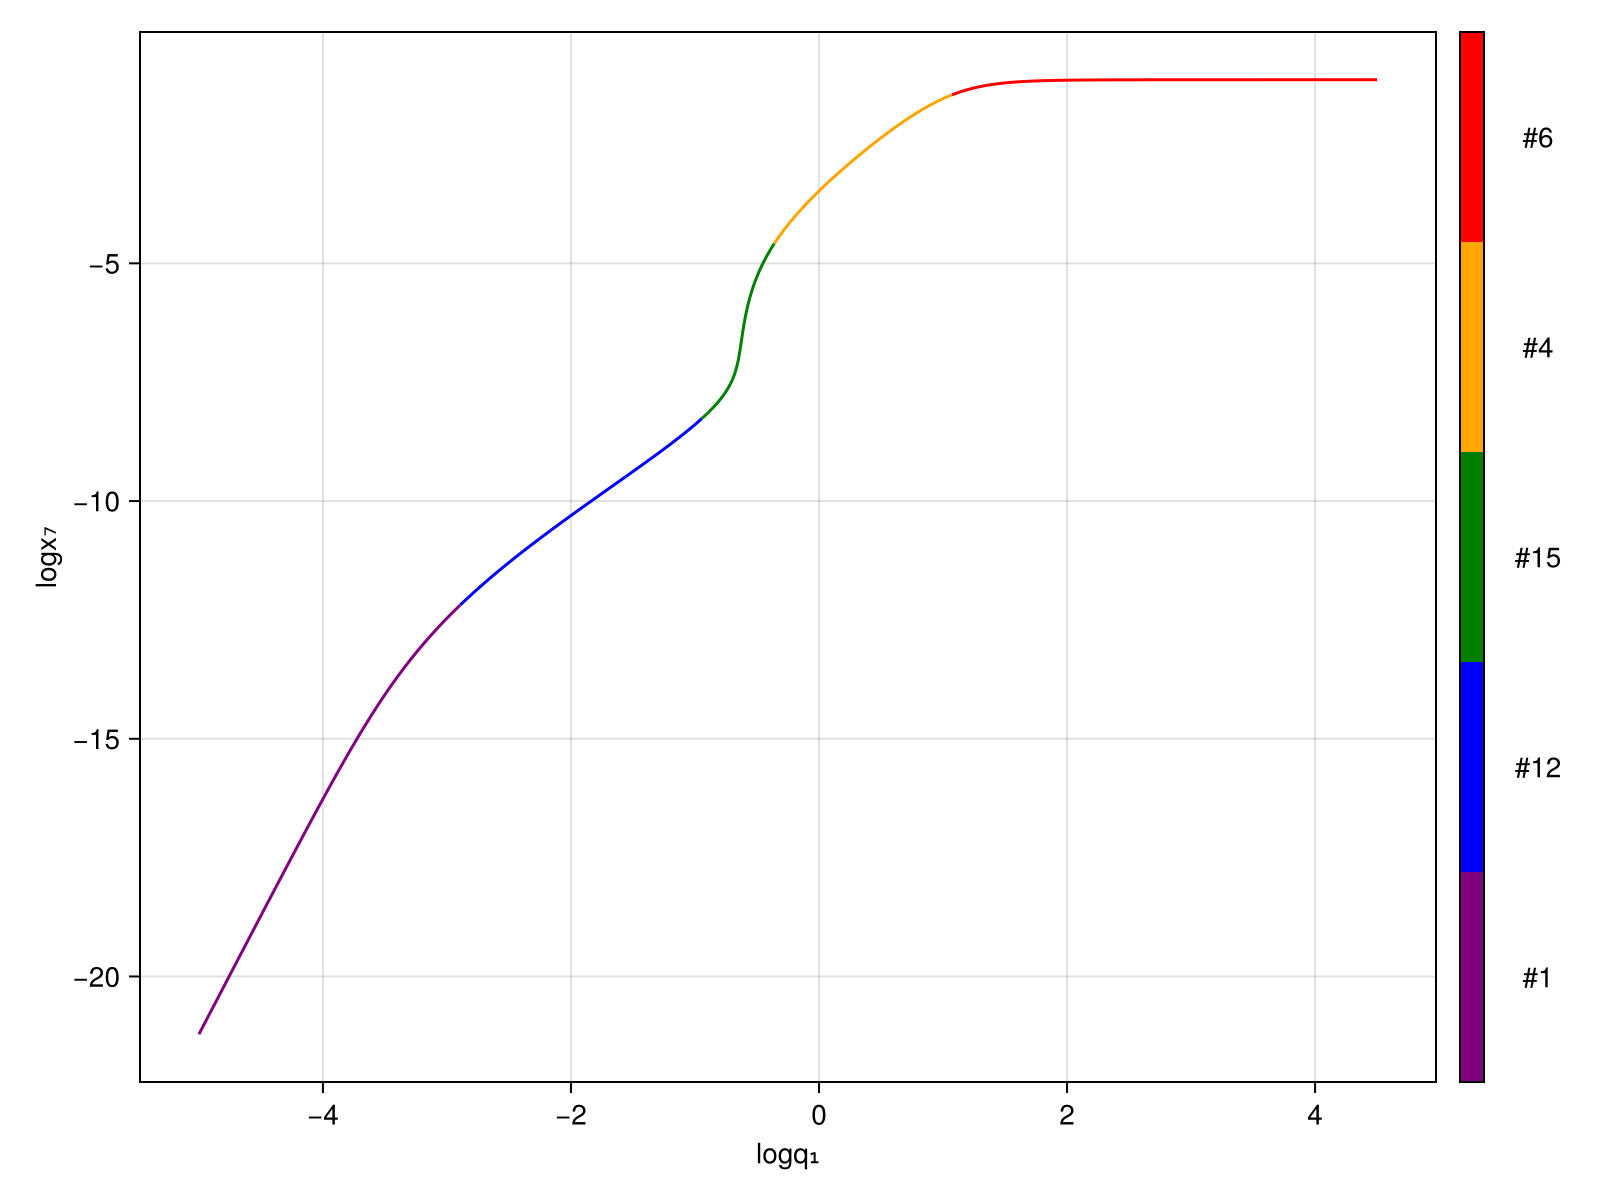

In [112]:
cond_s = get_one_inner_point(conds[700],extend=6,rand_line=false, rand_ray=false)
display(show_condition_poly(model,conds[700], ch_idx_2;log_space=false))
F = SISO_plot(model, cond_s, ch_idx_2; draw_idx=[7],npoints=10000,start=-5, stop=4.5,cmap=:rainbow, size = (800,600),asymptotic=false)

In [114]:
get_volume!(model,6)

isempty(kwargs) = true
total_counts = [278396]


(0.27839685127937036, 0.0008784730087353559)

In [59]:
L = [1 0 1 10
    0 1 1 1]
model = Bnc(L=L)

Bnc{Int8}([1 1 -1 0; 10 1 0 -1], [1 0 1 10; 0 1 1 1], 2, 4, 2, Num[x₁, x₂, x₃, x₄], Num[q₁, q₂], Num[K₁, K₂], nothing, Vector{Int8}[], Dict{Vector{Int8}, Int64}(), Bool[], Int8[], nothing, Vertex[], Bool[], false, Dict{Vector{Int8}, Tuple{SparseMatrixCSC{Float64, Int64}, Int8}}(), 1, [0.0, 0.0, 0.0, 0.0], [1.0791812460476249, 0.47712125471966244, 0.0, 0.0], false, sparse([1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4], [1, 1, 1, 1, 10, 1], 2, 4), sparse([1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4], [1, 1, 1, 1, 1, 1], 2, 4), [[1, 3, 4], [2, 3, 4]], [1, 3, 5], sparse([1, 2, 1, 2, 1, 2], [1, 1, 2, 2, 3, 4], [1, 10, 1, 1, -1, -1], 2, 4), sparse([1, 3, 4, 2, 3, 4, 1, 2, 3, 1, 2, 4], [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4], [1.0, 1.0, 10.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 10.0, 1.0, -1.0], 4, 4), [1, 4, 7, 8, 10, 11], [1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4], [2, 3, 5, 6, 9, 12], [3, 4, 3, 4, 3, 4], [1, 1, 2, 2, 3, 4], [1, 4], SparseArrays.UMFPACK.UmfpackLU{Float64, Int64}(SparseArrays.UMFPACK.Symbolic{Float64,

In [60]:
model.L

2×4 Matrix{Int64}:
 1  0  1  10
 0  1  1   1

In [71]:
assign_vertex_x(model,[0., 0., 5, 1];input_logspace=false,asymptotic=false)

nzval = [0.0, 0.0, 5.0, 5.0, 10.0, 1.0]


2-element Vector{Int8}:
 4
 3

In [48]:
is_asymptotic(model,25)

false

In [ ]:
save("/mnt/e/Pictures/Sequential_binding_n_5_example.svg", F)

CairoMakie.Screen{SVG}


In [128]:
calc_volume(model)

┌ Info: 🎯 相对误差达标 (≤ 0.5%) after 12700000 samples, 3.89 s
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:871
┌ Info: 总采样数: 12700000
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:877


26-element Vector{Tuple{Float64, Float64}}:
 (0.21521347196816695, 0.00022602507906802476)
 (0.03103675602385749, 9.537564703043302e-5)
 (0.024196521872399054, 8.450904371996043e-5)
 (0.02890770154973742, 9.21473142476375e-5)
 (0.05631596097590279, 0.00012678707306002835)
 (0.2777858939863258, 0.00024633959678629344)
 (0.2794014053086943, 0.00024677840190146655)
 (0.0, 0.0)
 (0.03585573094418082, 0.00010225770883115815)
 (0.0, 0.0)
 ⋮
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.018025106416276086, 7.317022889692701e-5)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)

In [417]:
n =10
model = Bnc(N=N_generator(n//2,n))
find_all_vertices!(model)
# summary(model)

MethodError: MethodError: no method matching N_generator(::Rational{Int64}, ::Int64)
The function `N_generator` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  N_generator(!Matched::Int64, ::Int64; min_binder, max_binder)
   @ Main ~/Realizibility_index/bnc_julia/bnc_helperfunctions.jl:172


In [141]:
function calc_volume(C::AbstractMatrix{<:Real}, C0::AbstractVector{<:Real}; 
    confidence_level::Float64=0.95,
    N=1_000_000,
    batch_size::Int=100_000,
    log_lower=-6,
    log_upper=6
)::Tuple{Float64,Float64}
    N = Int(N)

    n = size(C, 2)
    dist = Uniform(log_lower, log_upper)

    n_batches = cld(N, batch_size)  # 向上取整批次数
    counts = zeros(Int, n_batches)  # 每批结果

    Threads.@threads for b in 1:n_batches
        m = (b == n_batches) ? (N - (n_batches-1)*batch_size) : batch_size
        samples = rand(dist, n, m)
        vals = C * samples .+ C0

        local_count = 0
        @inbounds for j in 1:m
            if all(@view(vals[:, j]) .> 0)
                local_count += 1
            end
        end
        counts[b] = local_count
    end

    count = sum(counts)
    P_hat = count / N
    z = quantile(Normal(), (1 + confidence_level) / 2)

    # Wilson 置信区间
    denom = 1 + z^2 / N
    center = (P_hat + z^2/(2N)) / denom
    margin = (z / denom) * sqrt(P_hat*(1-P_hat)/N + z^2/(4N^2))

    return (center, margin)
end

calc_volume (generic function with 6 methods)

In [150]:
model = Bnc(N=[1 1 -1])

Bnc{Int8}([1 1 -1], [1 0 1; 0 1 1], 1, 3, 2, Num[x₁, x₂, x₃], Num[q₁, q₂], Num[K₁], nothing, Vector{Int8}[], Dict{Vector{Int8}, Int64}(), Bool[], Int8[], nothing, Vertex[], Bool[], false, Dict{Vector{Int8}, Tuple{SparseMatrixCSC{Float64, Int64}, Int8}}(), -1, [0.0, 0.0, 0.0], [0.3010299956639812, 0.3010299956639812, 0.0], false, sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 1, 1], 2, 3), sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 1, 1], 2, 3), [[1, 3], [2, 3]], [1, 2, 3], sparse([1, 1, 1], [1, 2, 3], [1, 1, -1], 1, 3), sparse([1, 3, 2, 3, 1, 2, 3], [1, 1, 2, 2, 3, 3, 3], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0], 3, 3), [1, 3, 5, 6], [1, 2, 1, 2], [1, 2, 3, 3], [2, 4, 7], [3, 3, 3], [1, 2, 3], [1, 3], SparseArrays.UMFPACK.UmfpackLU{Float64, Int64}(SparseArrays.UMFPACK.Symbolic{Float64, Int64}(Ptr{Nothing} @0x000000005356fd60), SparseArrays.UMFPACK.Numeric{Float64, Int64}(Ptr{Nothing} @0x00000000526e4fa0), 3, 3, [0, 2, 4, 7], [0, 2, 1, 2, 0, 1, 2], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0], 0, SparseA

In [156]:
summary(model)

----------Binding Network Summary:-------------
Number of species (n): 10
Number of conserved quantities (d): 5
Number of reactions (r): 5
L matrix: [1 0 0 0 0 2 0 2 0 1; 0 1 0 0 0 0 0 0 0 0; 0 0 1 0 0 0 0 0 0 1; 0 0 0 1 0 0 1 1 1 0; 0 0 0 0 1 0 1 0 2 0]
N matrix: [2 0 0 0 0 -1 0 0 0 0; 0 0 0 1 1 0 -1 0 0 0; 0 0 0 1 0 1 0 -1 0 0; 0 0 0 0 1 0 1 0 -1 0; 1 0 1 0 0 0 0 0 0 -1]
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 88
  - Invertible + Asymptotic: 50
  - Singular +  Asymptotic: 30
  - Invertible +  Non-Asymptotic: 7
  - Singular +  Non-Asymptotic: 1
-----------------------------------------------


In [158]:
a = calc_volume(model)

┌ Info: Processing 50 regimes
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:816


rel_errors = [0.0005941242703859002, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf]


┌ Info: Reach to the time limit: 20.078094959259033 s, stop
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:844
┌ Info: total_sample_num: 237100000
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:888


88-element Vector{Tuple{Float64, Float64}}:
 (0.043885389085388, 2.6073374770957492e-5)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 ⋮
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)
 (0.0, 0.0)

In [160]:
vtxs = get_vertices(model,singular=false,asymptotic=true)

50-element Vector{Vector{Int8}}:
 [1, 2, 3, 4, 5]
 [1, 2, 10, 4, 5]
 [1, 2, 3, 4, 7]
 [1, 2, 10, 4, 7]
 [1, 2, 3, 4, 9]
 [1, 2, 10, 4, 9]
 [1, 2, 3, 7, 5]
 [1, 2, 10, 7, 5]
 [1, 2, 3, 8, 5]
 [1, 2, 10, 8, 5]
 ⋮
 [8, 2, 10, 9, 5]
 [10, 2, 3, 4, 5]
 [10, 2, 3, 4, 7]
 [10, 2, 3, 4, 9]
 [10, 2, 3, 7, 5]
 [10, 2, 3, 8, 5]
 [10, 2, 3, 8, 7]
 [10, 2, 3, 8, 9]
 [10, 2, 3, 9, 5]

In [162]:
vtxs[2]

5-element Vector{Int8}:
  1
  2
 10
  4
  5

In [167]:
[calc_volume(model,vtxs[i]) for i in 1:50]

┌ Info: Processing 1 regimes
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:816


rel_errors = [0.004961247166030694]


┌ Info: Volume relative error is less than  0.5% after 3400000 samples, 0.33 s
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:883
┌ Info: total_sample_num: 3400000
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:888
┌ Info: Processing 1 regimes
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:816


rel_errors = [0.004985925653644112]


┌ Info: Volume relative error is less than  0.5% after 13000000 samples, 1.39 s
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:883
┌ Info: total_sample_num: 13000000
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:888
┌ Info: Processing 1 regimes
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:816


...

rel_errors = [0.006906012883511407]


┌ Info: Reach to the time limit: 20.007699966430664 s, stop
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:844
┌ Info: total_sample_num: 274300000
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:888
┌ Info: Processing 1 regimes
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:816


rel_errors = [0.004972786399870773]


┌ Info: Volume relative error is less than  0.5% after 1500000 samples, 0.1 s
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:883
┌ Info: total_sample_num: 1500000
└ @ Main /home/joker/Realizibility_index/bnc_julia/bnc_numeric.jl:888


50-element Vector{Tuple{Float64, Float64}}:
 (0.043887574157971024, 0.00021773710291519565)
 (0.011746990431063873, 5.856962094335327e-5)
 (0.0355113772175993, 0.0001769922737269886)
 (0.009698527609739866, 4.847675016523114e-5)
 (0.007453604492521738, 3.723302876227325e-5)
 (0.0020325021579024765, 1.0158906419475305e-5)
 (0.01639256535032748, 8.160928806685654e-5)
 (0.005383693663668058, 2.6912590751643654e-5)
 (0.007058566526000816, 3.522385832785923e-5)
 (0.014435987168967627, 7.21469054296379e-5)
 ⋮
 (0.0006818416249895421, 3.408472398039751e-6)
 (0.07596190996045331, 0.0003767147297722231)
 (0.07768295911237992, 0.0003806034803295229)
 (0.016626687566887333, 8.307838972687842e-5)
 (0.025424546281705554, 0.00012701499597129478)
 (0.005146540300643884, 2.569069412626209e-5)
 (0.0008544847938060223, 4.272078596393112e-6)
 (0.00029355056362285065, 2.0272639743414415e-6)
 (0.09384370682178335, 0.0004666647089968243)

In [5]:
zeros(eltype(N),10)

10-element Vector{Int64}:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0

In [2]:
N= [1 1 -1]

1×3 Matrix{Int64}:
 1  1  -1

In [419]:
model = Bnc(N=N)

Bnc{Int8}([1 1 -1], [1 0 1; 0 1 1], 1, 3, 2, Num[x₁, x₂, x₃], Num[q₁, q₂], Num[K₁], nothing, Vector{Int8}[], Dict{Vector{Int8}, Int64}(), Bool[], Int8[], nothing, Vertex[], Bool[], false, Dict{Vector{Int8}, Tuple{SparseMatrixCSC{Float64, Int64}, Int8}}(), -1, [0.0, 0.0, 0.0], [0.3010299956639812, 0.3010299956639812, 0.0], false, sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 1, 1], 2, 3), sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 1, 1], 2, 3), [[1, 3], [2, 3]], [1, 2, 3], sparse([1, 1, 1], [1, 2, 3], [1, 1, -1], 1, 3), sparse([1, 3, 2, 3, 1, 2, 3], [1, 1, 2, 2, 3, 3, 3], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0], 3, 3), [1, 3, 5, 6], [1, 2, 1, 2], [1, 2, 3, 3], [2, 4, 7], [3, 3, 3], [1, 2, 3], [1, 3], SparseArrays.UMFPACK.UmfpackLU{Float64, Int64}(SparseArrays.UMFPACK.Symbolic{Float64, Int64}(Ptr{Nothing} @0x0000000055ee31d0), SparseArrays.UMFPACK.Numeric{Float64, Int64}(Ptr{Nothing} @0x000000005632ccd0), 3, 3, [0, 2, 4, 7], [0, 2, 1, 2, 0, 1, 2], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0], 0, SparseA

## Test if julia two mutable struct can contain each other

In [6]:
mutable struct A
    b::Any
end


In [19]:
(1,2,3)[1:2]

(1, 2)

In [8]:
b(A::A) = A.b


b (generic function with 1 method)

In [18]:
deleteat!

deleteat! (generic function with 9 methods)

In [14]:
setdiff(1:end,4)

Base.Meta.ParseError: ParseError:
# Error @ /home/joker/Realizibility_index/bnc_julia/Examples/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y151sdnNjb2RlLXJlbW90ZQ==.jl:1:11
setdiff(1:end,4)
#         └ ── missing last argument in range expression

In [12]:
m

A([1, 2, 4, 5])